PHASE 4 — CUSTOMER SEGMENTATION (RFM + KMEANS)

GOAL:

Hum customers ko group karenge:

High-value customers
Loyal customers
At-risk customers
Lost customers

Using:

R = Recency
F = Frequency
M = Monetary

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Load Data
df = pd.read_csv("../data/cleaned/superstore_final.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Quarter,Shipping Days,Profit Margin
0,1,US-2023-103800,2023-01-03,2023-01-07,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512,2023,January,1,4,33.75
1,2,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870,2023,January,1,4,-155.00
2,3,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,Avery 508,11.784,3,0.2,4.2717,2023,January,1,4,36.25
3,4,US-2023-112326,2023-01-04,2023-01-08,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748,2023,January,1,4,-23.75
4,5,US-2023-141817,2023-01-05,2023-01-12,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840,2023,January,1,7,25.00


CREATE REFERENCE DATE

In [4]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

reference_date = df["Order Date"].max()
reference_date

Timestamp('2026-12-30 00:00:00')

BUILD RFM TABLE

In [5]:
rfm = df.groupby("Customer ID").agg({
    "Order Date": lambda x: (reference_date - x.max()).days,  # Recency
    "Order ID": "count",                                     # Frequency
    "Sales": "sum"                                            # Monetary
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
AA-10315,184,11,5563.560
AA-10375,19,15,1056.390
AA-10480,259,12,1790.512
AA-10645,55,18,5086.935
AB-10015,415,6,886.156


HANDLE OUTLIERS

In [6]:
rfm = rfm[rfm["Monetary"] > 0]

SCALING DATA

In [7]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

APPLY KMEANS CLUSTERING

In [8]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
Customer ID,,,,
AA-10315,184,11,5563.560,1
AA-10375,19,15,1056.390,1
AA-10480,259,12,1790.512,2
AA-10645,55,18,5086.935,1
AB-10015,415,6,886.156,0


ANALYZE CLUSTERS

In [9]:
rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,542.400000,7.800000,1574.658788
1,69.405694,17.448399,3605.490044
2,95.954674,8.617564,1504.427038
3,108.769231,22.000000,9492.149766


VISUALIZE CLUSTERS

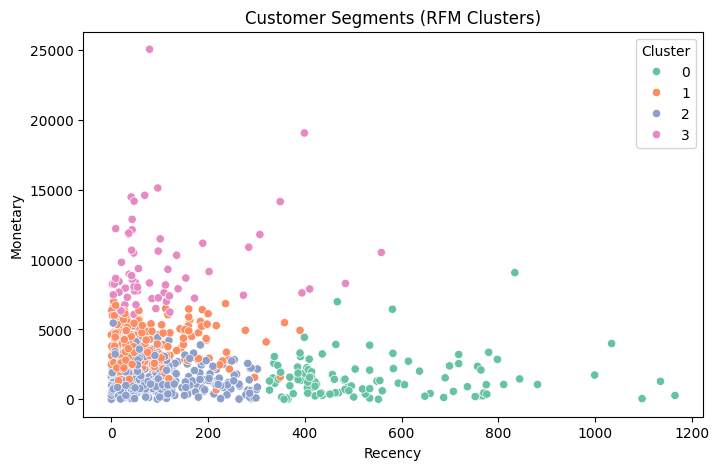

In [10]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments (RFM Clusters)")
plt.show()

3D VISUALIZATION

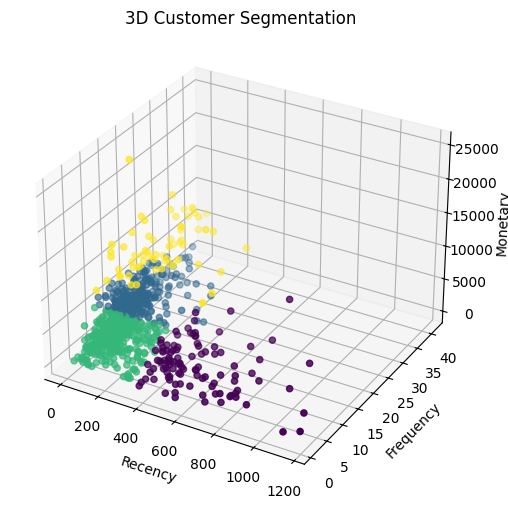

In [11]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=rfm["Cluster"]
)

ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.title("3D Customer Segmentation")
plt.show()

CUSTOMER LABELS

In [12]:
def label_customer(row):
    if row["Cluster"] == 0:
        return "Champions"
    elif row["Cluster"] == 1:
        return "Loyal Customers"
    elif row["Cluster"] == 2:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm.apply(label_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
AA-10315,184,11,5563.560,1,Loyal Customers
AA-10375,19,15,1056.390,1,Loyal Customers
AA-10480,259,12,1790.512,2,At Risk
AA-10645,55,18,5086.935,1,Loyal Customers
AB-10015,415,6,886.156,0,Champions


SEGMENT ANALYSIS

In [13]:
rfm["Segment"].value_counts()

Segment
At Risk            353
Loyal Customers    281
Champions          105
Lost                65
Name: count, dtype: int64

VISUALIZE SEGMENTS

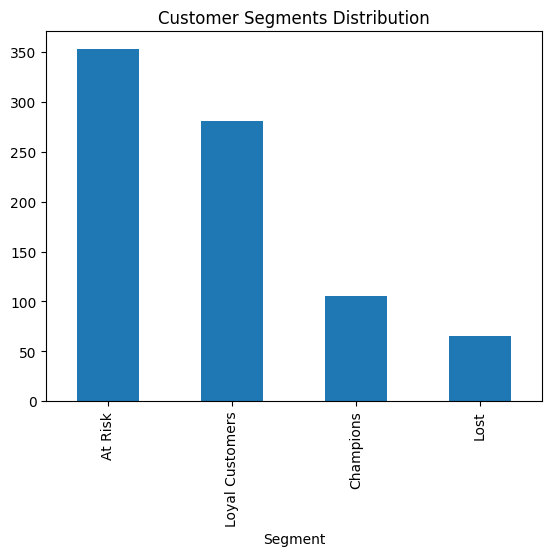

In [14]:
rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segments Distribution")
plt.show()

SAVE OUTPUTS

In [ ]:
import joblib
import os

os.makedirs("../models", exist_ok=True)
os.makedirs("../exports", exist_ok=True)

joblib.dump(kmeans, "../models/rfm_kmeans.pkl")
joblib.dump(scaler, "../models/rfm_scaler.pkl")

rfm.to_csv("../exports/rfm_segments.csv")

print("RFM Segmentation Completed")

RFM Segmentation Completed
